In [2]:
from google.colab import files
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from PIL import Image
import imghdr

# 1. Upload your kaggle.json file
print("Please upload your kaggle.json file:")
files.upload()

# 2. Setup Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download and extract the dataset
!kaggle datasets download -d utkarshsaxenadn/fast-food-classification-dataset
!unzip -q fast-food-classification-dataset.zip -d fast_food_data
print("Dataset downloaded and extracted successfully!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/fast-food-classification-dataset
License(s): CC0-1.0
100% 821M/821M [00:09<00:00, 87.1MB/s]

Dataset downloaded and extracted successfully!


In [4]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imghdr

from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

data_dir = "/content/fast_food_data/Fast Food Classification V2/Train"
val_dir  = "/content/fast_food_data/Fast Food Classification V2/Valid"

assert os.path.isdir(data_dir), f"Train dir not found: {data_dir}"
assert os.path.isdir(val_dir), f"Valid dir not found: {val_dir}"

In [5]:
def deep_clean_images(folder):
    valid_ext = {"jpeg", "jpg", "png", "bmp", "gif", "webp"}
    removed = 0

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue

        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            try:
                ext = imghdr.what(fpath)
                if ext not in valid_ext:
                    os.remove(fpath)
                    removed += 1
                    continue

                img = Image.open(fpath)
                img.verify()
            except Exception:
                if os.path.exists(fpath):
                    os.remove(fpath)
                    removed += 1

    print(f"[CLEAN] Removed {removed} corrupted files from {folder}")

deep_clean_images(data_dir)
deep_clean_images(val_dir)

[CLEAN] Removed 1 corrupted files from /content/fast_food_data/Fast Food Classification V2/Train
[CLEAN] Removed 0 corrupted files from /content/fast_food_data/Fast Food Classification V2/Valid


In [6]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
num_classes = len(class_names)

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

print(f"Classes ({num_classes}): {class_names}")

Found 14999 files belonging to 10 classes.
Found 3500 files belonging to 10 classes.
Classes (10): ['Baked Potato', 'Burger', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Pizza', 'Sandwich', 'Taco', 'Taquito']


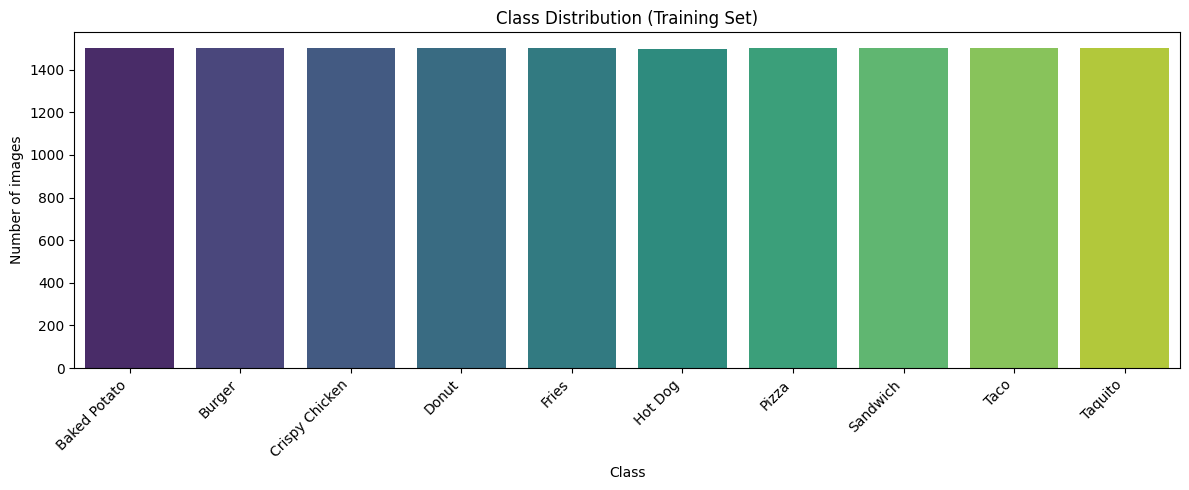

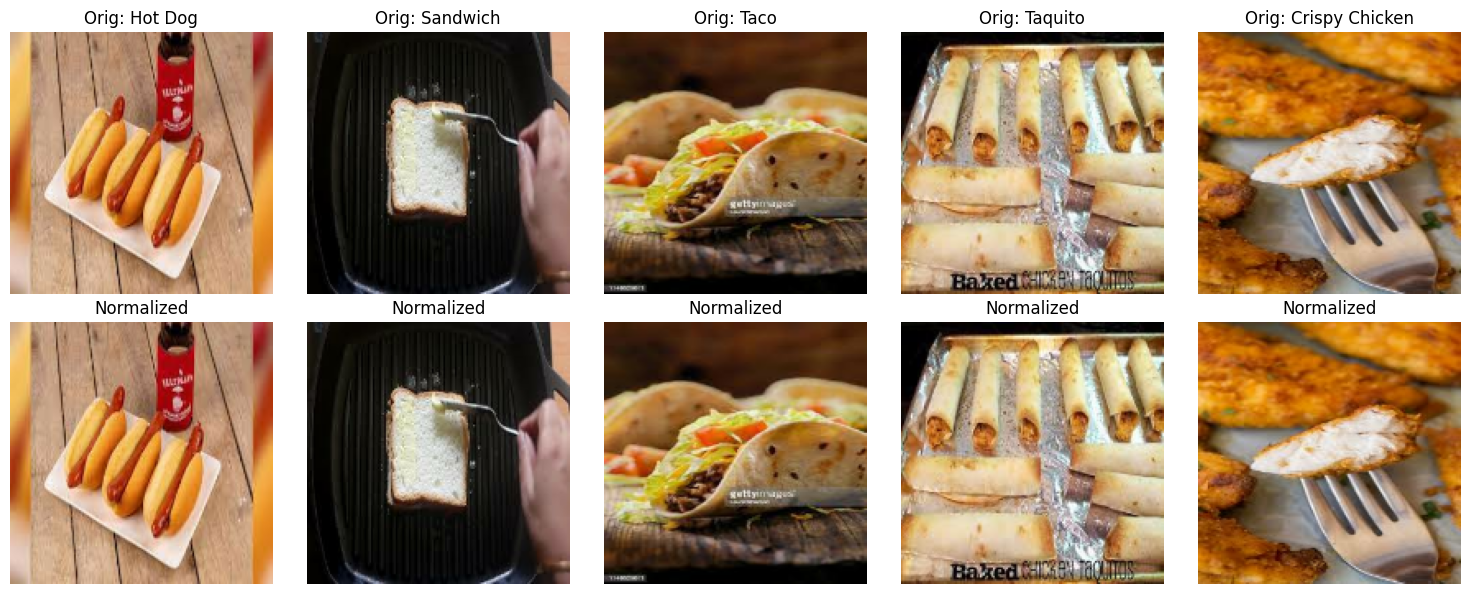

In [7]:
# Class distribution
class_counts = {
    name: len([f for f in os.listdir(os.path.join(data_dir, name))
               if os.path.isfile(os.path.join(data_dir, name, f))])
    for name in class_names
}

plt.figure(figsize=(12, 5))
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values()),
    hue=list(class_counts.keys()),
    legend=False,
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

# Preprocessing sample: original vs normalized
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(15, 6))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Orig: {class_names[labels[i]]}")
        plt.axis("off")

        plt.subplot(2, 5, i + 6)
        norm_img = images[i].numpy() / 255.0
        plt.imshow(norm_img)
        plt.title("Normalized")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
def collect_val_arrays(val_ds):
    x_list, y_list = [], []
    for x_batch, y_batch in val_ds:
        x_list.append(x_batch.numpy())
        y_list.append(y_batch.numpy())
    x = np.concatenate(x_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return x, y

val_images, val_labels = collect_val_arrays(val_dataset)

def plot_training_curves(history, model_name):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["accuracy"], marker="o", label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], marker="o", label="Val Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    plt.plot(epochs, hist["val_loss"], marker="o", label="Val Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_and_plot(model, history, model_name):
    # 1) Train/Val curves
    plot_training_curves(history, model_name)

    # 2) Predictions
    probs = model.predict(val_images, verbose=0)
    preds = np.argmax(probs, axis=1)

    # 3) Confusion Matrix
    cm = confusion_matrix(val_labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 4) ROC Curves
    y_true_bin = label_binarize(val_labels, classes=np.arange(num_classes))
    plt.figure(figsize=(8, 6))
    aucs = []

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.title(f"{model_name} - ROC Curves (Macro AUC={np.mean(aucs):.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8, loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5) Precision / Recall / F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        val_labels, preds, average=None, labels=np.arange(num_classes), zero_division=0
    )

    x = np.arange(num_classes)
    width = 0.25

    plt.figure(figsize=(12, 6))
    plt.bar(x - width, precision, width, label="Precision")
    plt.bar(x, recall, width, label="Recall")
    plt.bar(x + width, f1, width, label="F1-score")
    plt.xticks(x, class_names, rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(f"{model_name} - Per-Class Precision/Recall/F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_val_acc = float(np.max(history.history["val_accuracy"]))
    return best_val_acc


=== Training Model 1: Turbo Residual CNN ===
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.2746 - loss: 2.0643 - val_accuracy: 0.1803 - val_loss: 3.7330 - learning_rate: 0.0020
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.3584 - loss: 1.8615 - val_accuracy: 0.2060 - val_loss: 2.5939 - learning_rate: 0.0020
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.4115 - loss: 1.7424 - val_accuracy: 0.1409 - val_loss: 3.7082 - learning_rate: 0.0020
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.4458 - loss: 1.6502 - val_accuracy: 0.1829 - val_loss: 2.7706 - learning_rate: 0.0020
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.5194 - loss: 1.4565 - val_accuracy: 0.4100 - val_loss: 1.8587 - learning_rate: 4.0000e-04
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.5382 - loss: 1.3851 - val_accuracy: 0.4046 - val_loss: 1.9099 - learning_rate: 4.0000e-04
Epoch 7/20
469/469 ━━━

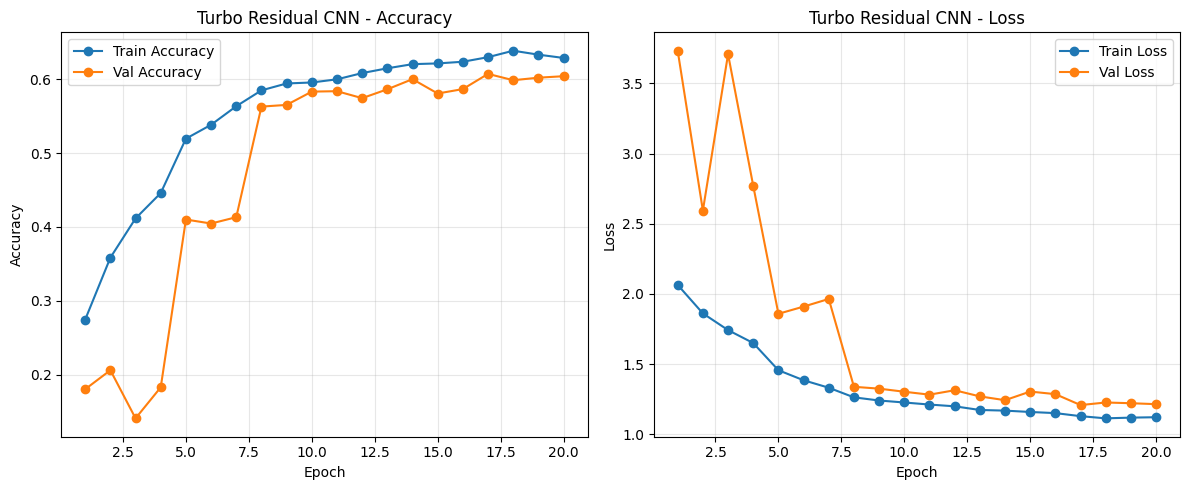

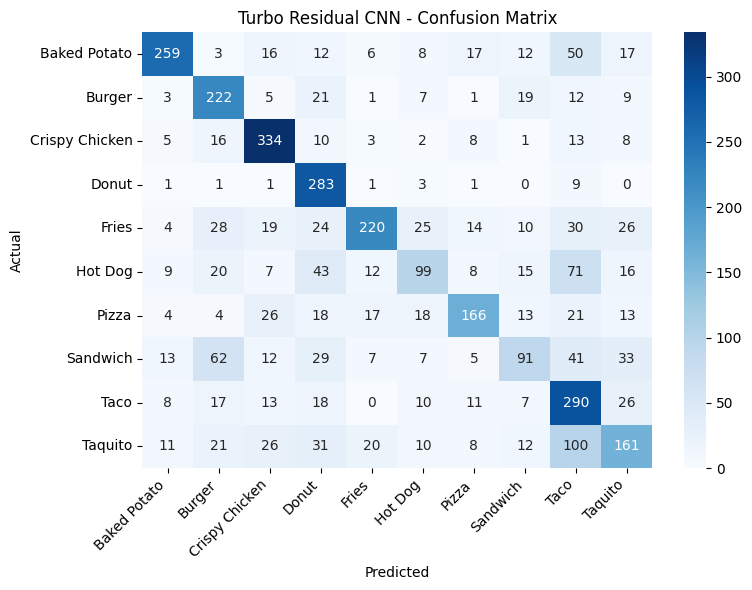

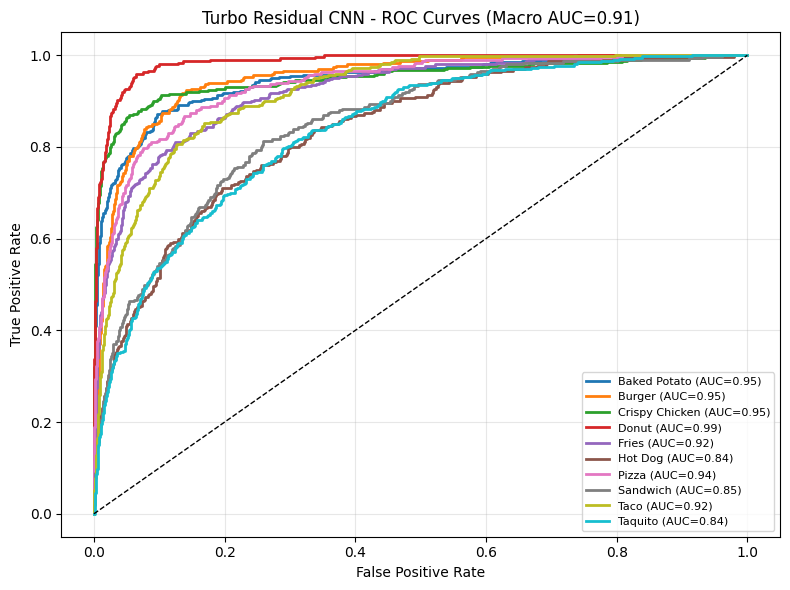

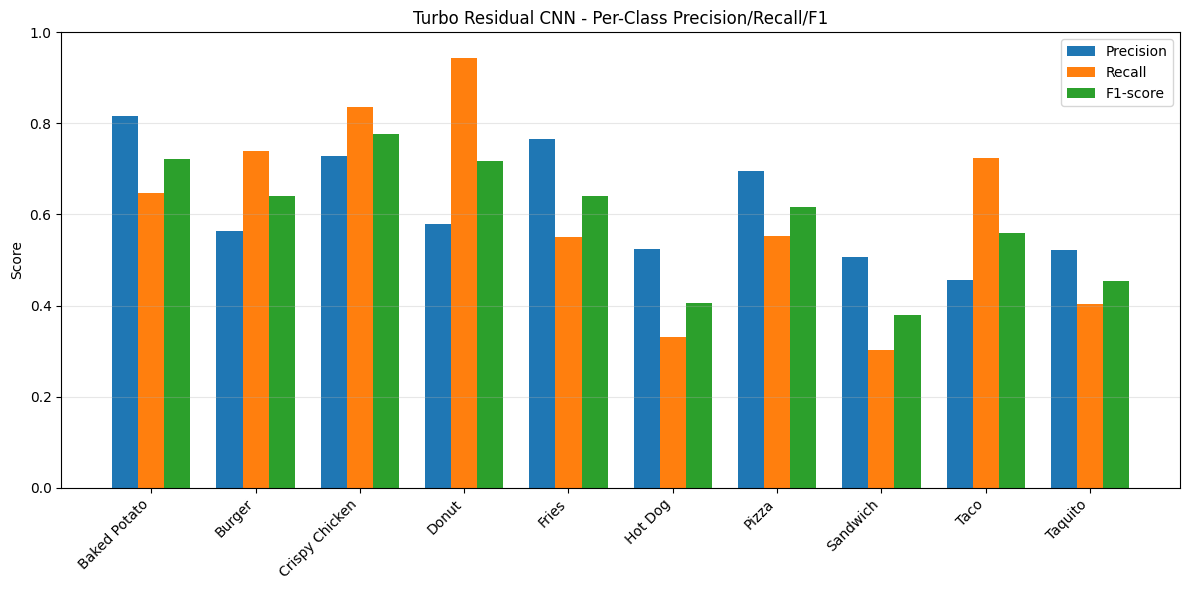

In [9]:
print("\n=== Training Model 1: Turbo Residual CNN ===")
tf.keras.backend.clear_session()
mixed_precision.set_global_policy("mixed_float16")

def fast_residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

aug_turbo = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inp = layers.Input(shape=(160, 160, 3))
x = aug_turbo(inp)
x = layers.Rescaling(1.0 / 255)(x)

x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

x = fast_residual_block(x, 64)
x = fast_residual_block(x, 128)
x = layers.MaxPooling2D(2)(x)
x = fast_residual_block(x, 256)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

fast_res_model = tf.keras.Model(inp, out, name="TurboResidualCNN")
fast_res_model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_turbo = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

fast_history = fast_res_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks_turbo,
    verbose=1
)

turbo_best_acc = evaluate_and_plot(fast_res_model, fast_history, "Turbo Residual CNN")


=== Training Model 2: Transfer Learning (MobileNetV2) ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Warmup
Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6380 - loss: 1.3613 - val_accuracy: 0.7466 - val_loss: 0.9097
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.7136 - loss: 0.9334 - val_accuracy: 0.7691 - val_loss: 0.7880
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.7378 - loss: 0.8259 - val_accuracy: 0.7726 - val_loss: 0.7565
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.7523 - loss: 0.7625 - val_accuracy: 0.7806 - val_loss: 0.7126
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.7581 - loss: 0.7419 - val_accuracy: 0.7786 - val_loss: 0.7332
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.7693 - loss: 0.7130 - val_accuracy: 0.7760 - val_loss: 0.7290
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.7677 - loss: 0.7098 - val_accuracy:

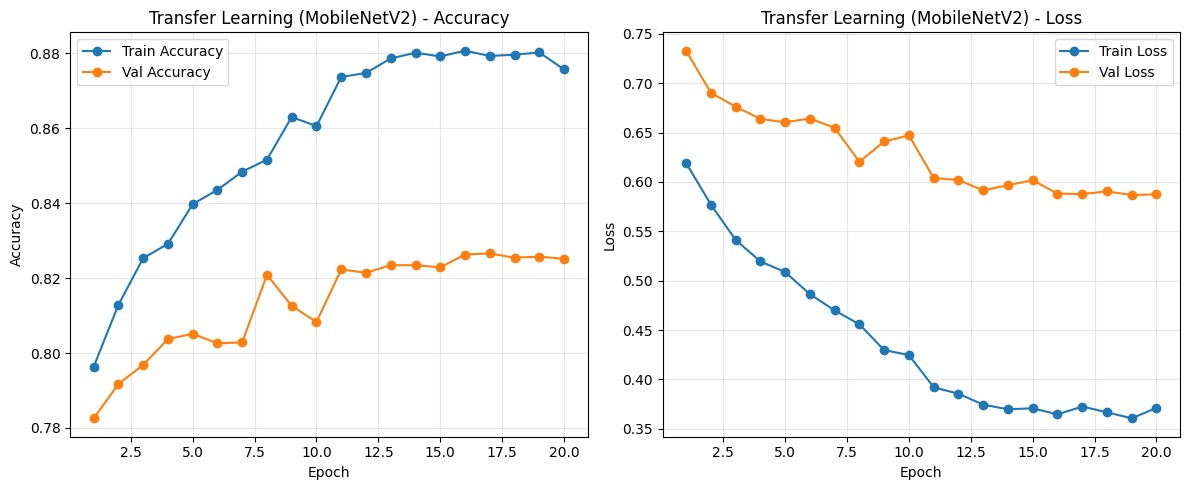

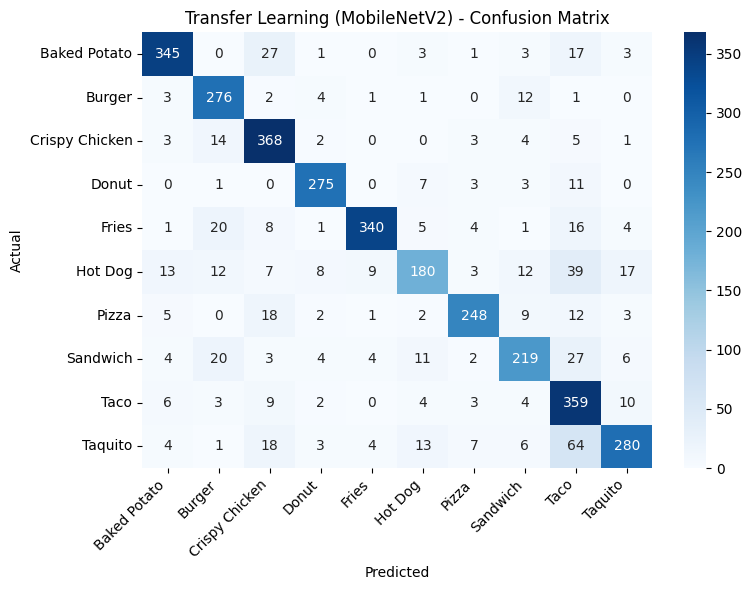

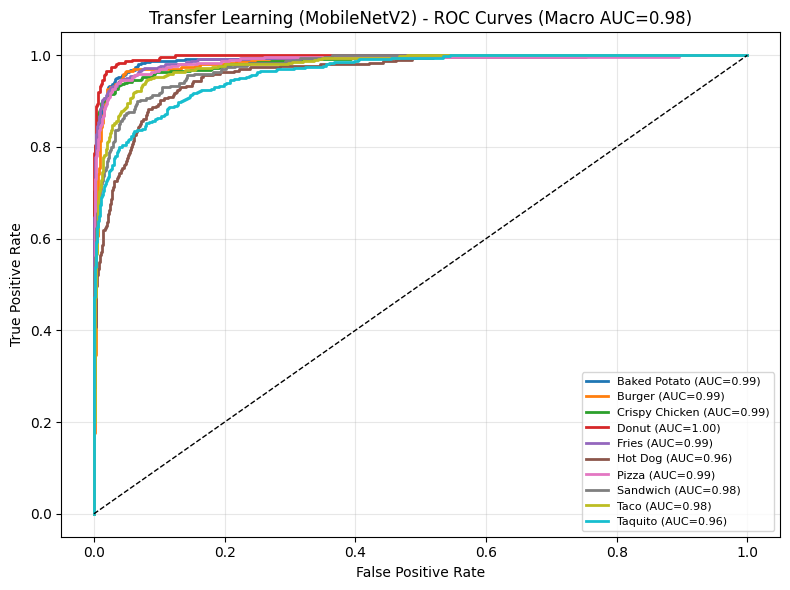

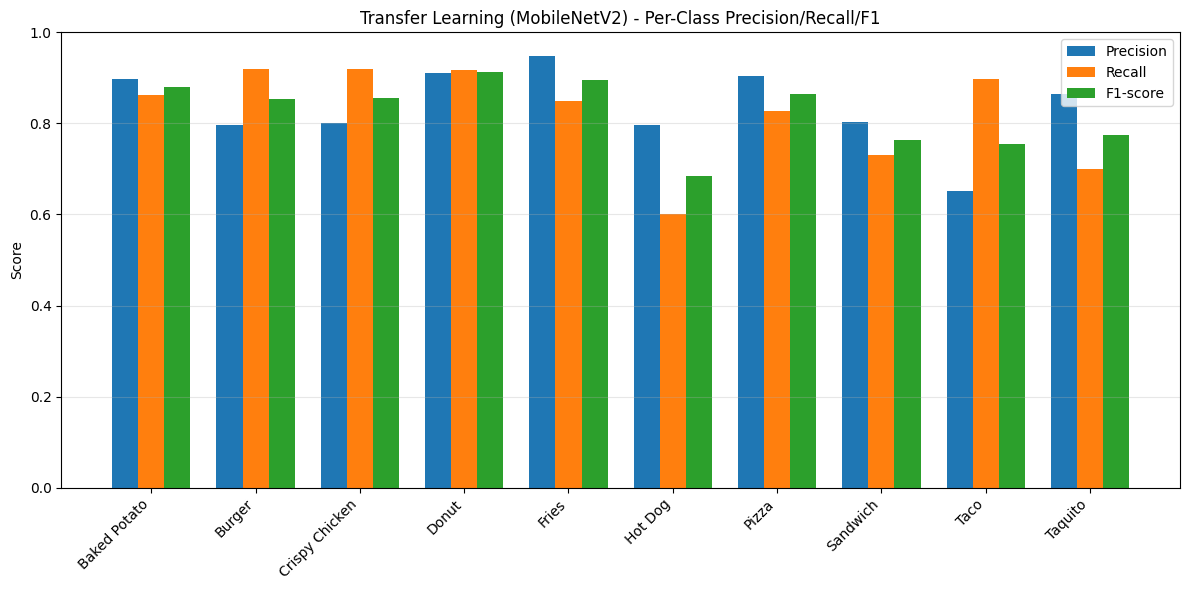

In [10]:
print("\n=== Training Model 2: Transfer Learning (MobileNetV2) ===")
tf.keras.backend.clear_session()
mixed_precision.set_global_policy("float32")

aug_transfer = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inp = layers.Input(shape=(160, 160, 3))
x = aug_transfer(inp)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
x = base_model(x, training=False)

avg_pool = layers.GlobalAveragePooling2D()(x)
max_pool = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_pool, max_pool])

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = models.Model(inp, out, name="MobileNetV2_Transfer")

reduce_lr_t = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7)
early_stop_t = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Phase 1
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Phase 1: Warmup")
_ = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=8,
    callbacks=[early_stop_t],
    verbose=1
)

# Phase 2
print("Phase 2: Fine-tuning")
base_model.trainable = True
fine_tune_at = 70

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[reduce_lr_t, early_stop_t],
    verbose=1
)

transfer_best_acc = evaluate_and_plot(transfer_model, history, "Transfer Learning (MobileNetV2)")


=== Training Model 3: Vision Transformer ===
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 252ms/step - accuracy: 0.1919 - loss: 2.1894 - val_accuracy: 0.2463 - val_loss: 2.0327 - learning_rate: 1.0000e-04
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - accuracy: 0.2713 - loss: 2.0162 - val_accuracy: 0.3106 - val_loss: 1.9950 - learning_rate: 1.0000e-04
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - accuracy: 0.3485 - loss: 1.8675 - val_accuracy: 0.3740 - val_loss: 1.8168 - learning_rate: 1.0000e-04
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - accuracy: 0.3894 - loss: 1.7536 - val_accuracy: 0.4554 - val_loss: 1.6206 - learning_rate: 1.0000e-04
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - accuracy: 0.4328 - loss: 1.6606 - val_accuracy: 0.4691 - val_loss: 1.5841 - learning_rate: 1.0000e-04
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 250ms/step - accuracy: 0.4576 - loss: 1.5874 - val_accuracy: 0.4780 - val_loss: 1.5556 - learning_rate: 1.000

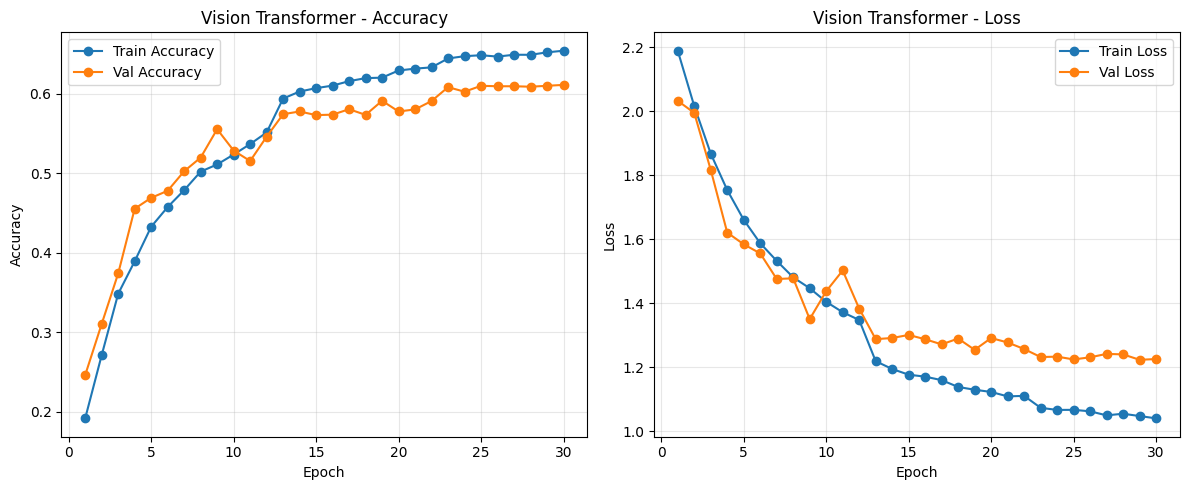

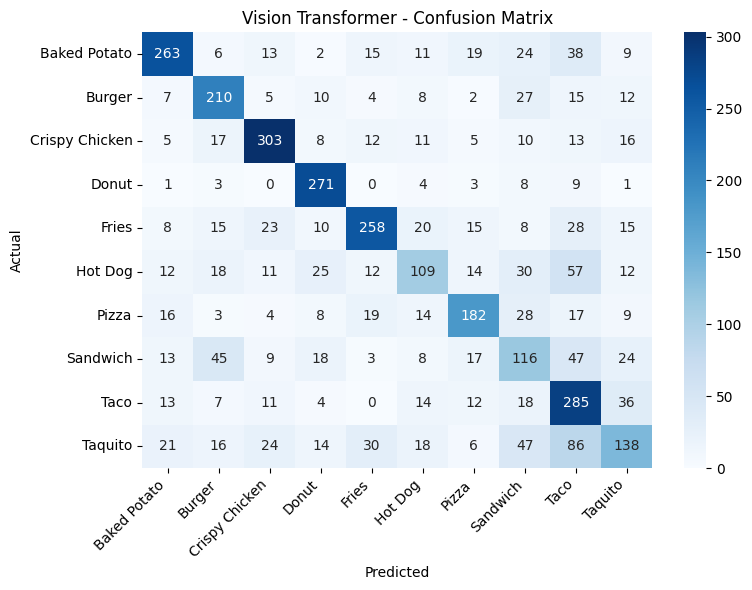

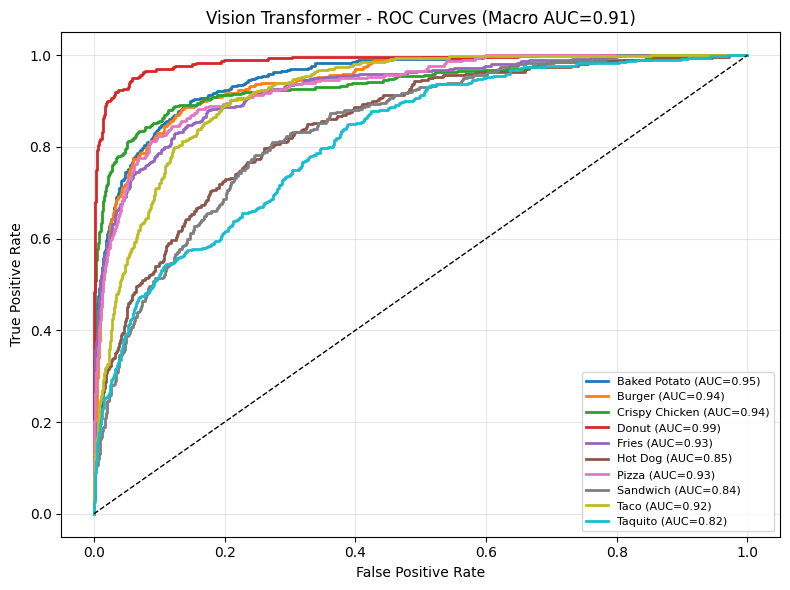

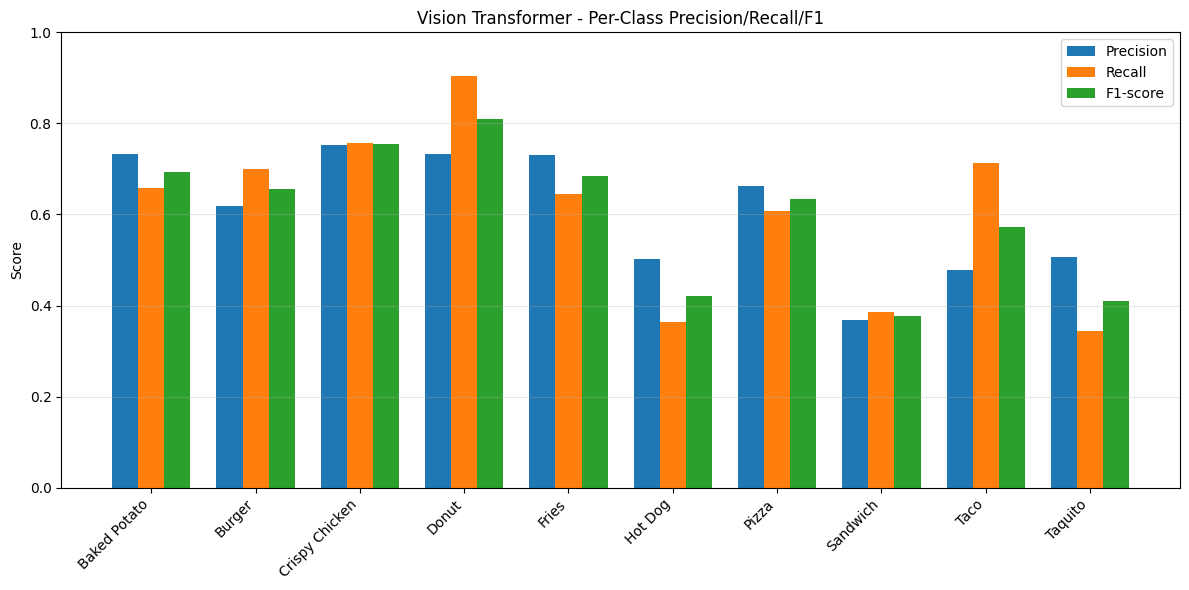

In [11]:
print("\n=== Training Model 3: Vision Transformer ===")
tf.keras.backend.clear_session()

patch_size = 10
num_patches = (IMG_SIZE[0] // patch_size) ** 2
projection_dim = 128
num_heads = 8
transformer_layers = 6
transformer_units = [projection_dim * 2, projection_dim]
mlp_head_units = [2048, 1024]

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)

inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])(inp)

x = layers.Rescaling(1.0 / 255)(aug)
patches = Patches(patch_size)(x)
encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

for _ in range(transformer_layers):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=0.1
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
    encoded_patches = layers.Add()([x3, x2])

representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)
representation = layers.Dropout(0.3)(representation)
features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)
out = layers.Dense(num_classes, activation="softmax")(features)

vit_model = tf.keras.Model(inputs=inp, outputs=out, name="VisionTransformer")
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

early_stop_v = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr_v = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6)

history_vit = vit_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop_v, reduce_lr_v],
    verbose=1
)

vit_best_acc = evaluate_and_plot(vit_model, history_vit, "Vision Transformer")

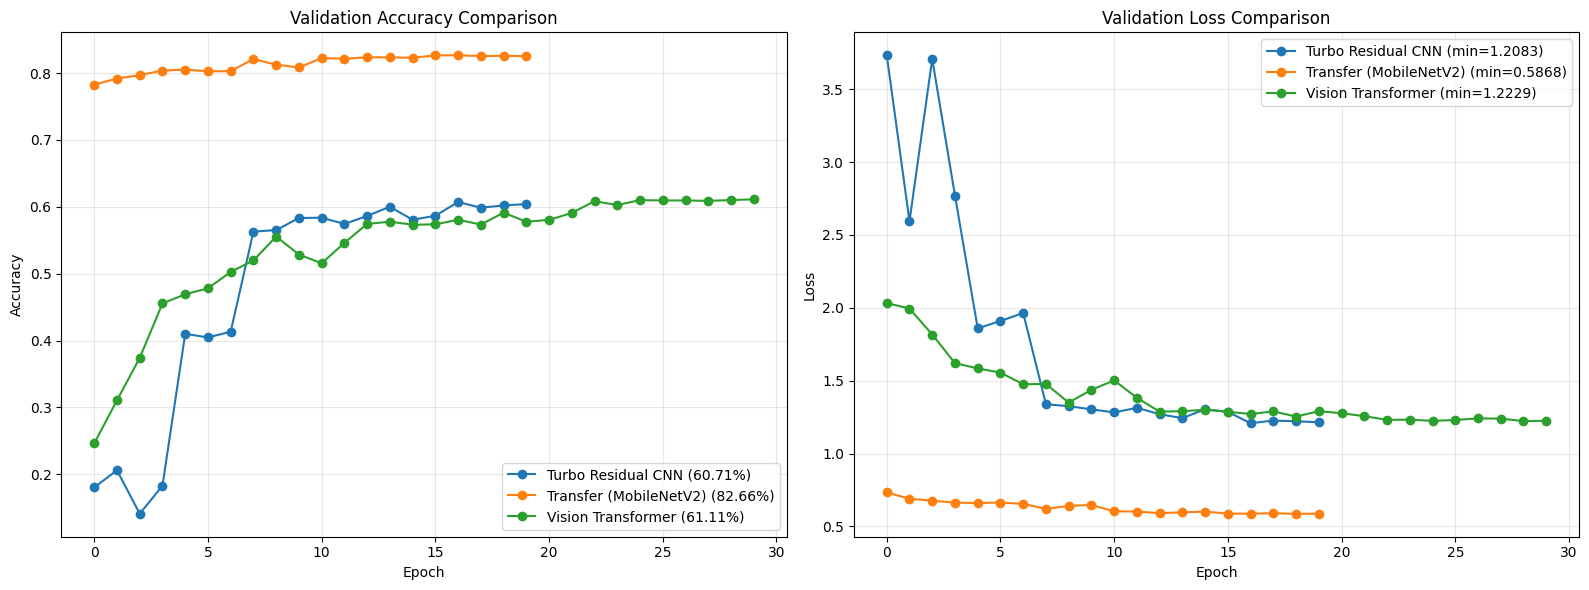

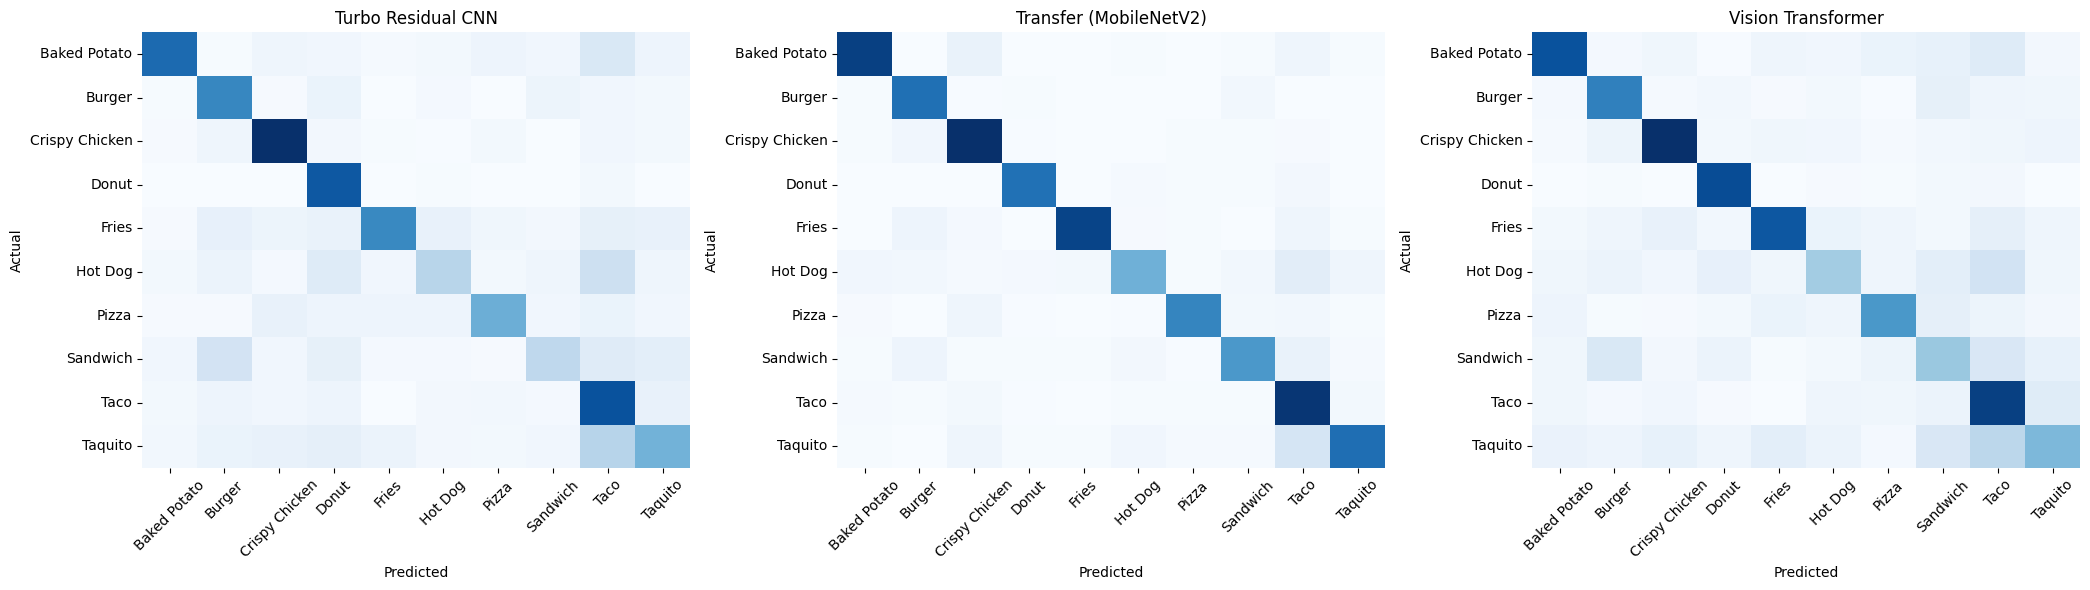


FINAL VALIDATION LEADERBOARD
1. Transfer (MobileNetV2)       | 82.66%
2. Vision Transformer           | 61.11%
3. Turbo Residual CNN           | 60.71%


In [12]:
comparison_data = {
    "Turbo Residual CNN": (fast_history, fast_res_model, turbo_best_acc),
    "Transfer (MobileNetV2)": (history, transfer_model, transfer_best_acc),
    "Vision Transformer": (history_vit, vit_model, vit_best_acc),
}

# Validation Accuracy/Loss comparison
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
for name, (hist, _, best_acc) in comparison_data.items():
    plt.plot(hist.history["val_accuracy"], marker="o", label=f"{name} ({best_acc:.2%})")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
for name, (hist, _, _) in comparison_data.items():
    plt.plot(hist.history["val_loss"], marker="o", label=f"{name} (min={min(hist.history['val_loss']):.4f})")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for idx, (name, (_, model, _)) in enumerate(comparison_data.items()):
    probs = model.predict(val_images, verbose=0)
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(val_labels, preds)

    sns.heatmap(
        cm,
        annot=False,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx]
    )
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].tick_params(axis="x", rotation=45)
    axes[idx].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# Leaderboard
results = sorted(
    [(name, score) for name, (_, _, score) in comparison_data.items()],
    key=lambda x: x[1],
    reverse=True
)

print("\n" + "=" * 50)
print("FINAL VALIDATION LEADERBOARD")
print("=" * 50)
for i, (name, score) in enumerate(results, start=1):
    print(f"{i}. {name:28s} | {score:.2%}")
print("=" * 50)